<a href="https://colab.research.google.com/github/aleenaqeel/DFR-WaterBirds-Reproduction/blob/Milestone2/DFR_Waterbirds_Reproduction_Week3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# DFR Reproduction — Waterbirds (Group 4)
**Paper:** Kirichenko, Izmailov & Wilson, *Last Layer Re-Training is Sufficient for Robustness to Spurious Correlations*, ICLR 2023.




## 0. Setup — GPU check, installs, Drive mount

In [ ]:
# Confirm you actually got a GPU.
import torch
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
else:
    print("No GPU detected — training will be very slow on CPU. Fix this before continuing.")


CUDA available: True
GPU: Tesla T4


In [ ]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

import os
PROJECT_DIR = '/content/drive/MyDrive/dfr_waterbirds_project'
os.makedirs(PROJECT_DIR, exist_ok=True)
CKPT_DIR = os.path.join(PROJECT_DIR, 'checkpoints')
RESULTS_DIR = os.path.join(PROJECT_DIR, 'results')
os.makedirs(CKPT_DIR, exist_ok=True)
os.makedirs(RESULTS_DIR, exist_ok=True)
print("Project dir:", PROJECT_DIR)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Project dir: /content/drive/MyDrive/dfr_waterbirds_project


In [ ]:

!pip install -q wilds==2.0.0

import wilds
print("wilds version:", wilds.__version__)


wilds version: 2.0.0


## 1. Dataset — Waterbirds via the WILDS package

We use the `wilds` package: it fetches the exact
Waterbirds benchmark (CUB birds composited onto Places backgrounds, 95% train correlation,
balanced val/test).

**Groups (4 total)**, defined as `y (label) x background`:
- 0: landbird on land
- 1: landbird on water
- 2: waterbird on land  
- 3: waterbird on water


In [ ]:
from wilds import get_dataset
import torchvision.transforms as T
import subprocess

DATA_ROOT = '/content/waterbirds_data'
os.makedirs(DATA_ROOT, exist_ok=True)


WATERBIRDS_DIR = os.path.join(DATA_ROOT, 'waterbirds_v1.0')
os.makedirs(WATERBIRDS_DIR, exist_ok=True)

def already_downloaded():
    return os.path.exists(os.path.join(WATERBIRDS_DIR, 'metadata.csv'))

if not already_downloaded():
    print("Downloading Waterbirds directly (bypassing the flaky CodaLab source)...")
    mirrors = [
        "https://nlp.stanford.edu/data/dro/waterbird_complete95_forest2water2.tar.gz",
        "https://downloads.cs.stanford.edu/nlp/data/dro/waterbird_complete95_forest2water2.tar.gz",
    ]
    tar_path = "/tmp/waterbirds.tar.gz"
    ok = False
    for url in mirrors:
        print("Trying:", url)
        ret = subprocess.run(["wget", "-q", url, "-O", tar_path])
        # the real archive is roughly 1.1GB -- if we got a tiny file, that mirror failed too
        if ret.returncode == 0 and os.path.exists(tar_path) and os.path.getsize(tar_path) > 10_000_000:
            print("  -> downloaded", os.path.getsize(tar_path) // (1024*1024), "MB")
            ok = True
            break
        print("  -> failed or file too small, trying next mirror")

    if not ok:
        raise RuntimeError(
            "Automatic download failed from every mirror (unusual -- possibly a Colab network hiccup, "
            "just rerun this cell). If it keeps failing: download "
            "https://nlp.stanford.edu/data/dro/waterbird_complete95_forest2water2.tar.gz manually in your "
            "browser, upload the .tar.gz into your Drive project folder, set tar_path above to that "
            "file's path, and rerun this cell."
        )

    print("Extracting (this takes a minute, ~11,800 images)...")

    subprocess.run(["tar", "-xzf", tar_path, "-C", WATERBIRDS_DIR, "--strip-components=1"])
    print("Done. metadata.csv present:", already_downloaded())
else:
    print("Waterbirds already present locally -- skipping download.")

dataset = get_dataset(dataset="waterbirds", download=False, root_dir=DATA_ROOT)

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

transform_train = T.Compose([
    T.RandomResizedCrop(224, scale=(0.7, 1.0)),
    T.RandomHorizontalFlip(),
    T.ToTensor(),
    T.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

transform_eval = T.Compose([
    T.Resize(256),
    T.CenterCrop(224),
    T.ToTensor(),
    T.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

train_data = dataset.get_subset('train', transform=transform_train)
val_data   = dataset.get_subset('val',   transform=transform_eval)
test_data  = dataset.get_subset('test',  transform=transform_eval)

print("Train size:", len(train_data))
print("Val size:  ", len(val_data))
print("Test size: ", len(test_data))
print("Metadata fields:", dataset.metadata_fields)


/usr/local/lib/python3.13/dist-packages/outdated/__init__.py:36: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import parse_version


Waterbirds already present locally -- skipping download.
Train size: 4795
Val size:   1199
Test size:  5794
Metadata fields: ['background', 'y', 'from_source_domain']


In [ ]:
BG_IDX = dataset.metadata_fields.index('background')
Y_IDX  = dataset.metadata_fields.index('y')

def group_ids_from_metadata(y, metadata):
    """y: tensor of labels [B]; metadata: tensor [B, num_fields] as returned by the loader."""
    background = metadata[:, BG_IDX]
    return (y * 2 + background).long()

GROUP_NAMES = {
    0: "landbird / land  (majority)",
    1: "landbird / water (minority)",
    2: "waterbird / land (minority)",
    3: "waterbird / water (majority)",
}


## 2. A Few Examples

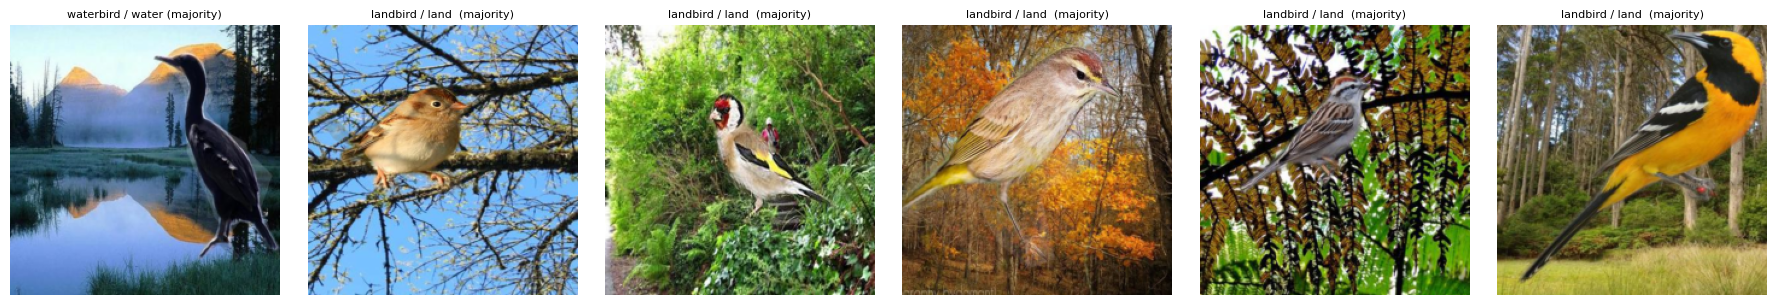

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

def denormalize(img_tensor):
    img = img_tensor.numpy().transpose(1, 2, 0)
    img = img * np.array(IMAGENET_STD) + np.array(IMAGENET_MEAN)
    return np.clip(img, 0, 1)

fig, axes = plt.subplots(1, 6, figsize=(18, 3))
idxs = np.random.choice(len(train_data), 6, replace=False)
for ax, idx in zip(axes, idxs):
    x, y, meta = train_data[idx]
    g = group_ids_from_metadata(torch.tensor([y]), meta.unsqueeze(0)).item()
    ax.imshow(denormalize(x))
    ax.set_title(GROUP_NAMES[g], fontsize=8)
    ax.axis('off')
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'sample_groups.png'), dpi=120)
plt.show()


## 3. Dataloaders

In [ ]:
from wilds.common.data_loaders import get_train_loader, get_eval_loader

BATCH_SIZE = 32

train_loader = get_train_loader('standard', train_data, batch_size=BATCH_SIZE, num_workers=2)
val_loader   = get_eval_loader('standard', val_data,   batch_size=128, num_workers=2)
test_loader  = get_eval_loader('standard', test_data,  batch_size=128, num_workers=2)

print("Batches per epoch (train):", len(train_loader))


Batches per epoch (train): 150


## 4. Sanity check — one batch, check shapes, check loss is finite



In [ ]:
import torch.nn as nn
import torchvision.models as models

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

def build_resnet50(num_classes=2):
    m = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V2)
    m.fc = nn.Linear(m.fc.in_features, num_classes)
    return m

model = build_resnet50().to(device)

x, y, meta = next(iter(train_loader))
x, y = x.to(device), y.to(device)
with torch.no_grad():
    logits = model(x)
loss = nn.functional.cross_entropy(logits, y)

print("Batch image shape:", x.shape)
print("Logits shape:     ", logits.shape)
print("Loss (untrained, should be ~ln(2)=0.693 and finite):", loss.item())
assert torch.isfinite(loss), "Loss is not finite -- stop and debug before training."
print("Forward pass OK.")


Batch image shape: torch.Size([32, 3, 224, 224])
Logits shape:      torch.Size([32, 2])
Loss (untrained, should be ~ln(2)=0.693 and finite): 0.6906523704528809
Forward pass OK.


## 5. Train the ERM baseline

This is the "before" model — standard cross-entropy training on the imbalanced training set,
no group information used at all. We evaluate per-group accuracy on val/test after every epoch
so we can watch the worst-group accuracy stay low even as overall accuracy climbs (that gap
*is* the phenomenon the paper is about).


In [ ]:
@torch.no_grad()
def evaluate(model, loader):
    model.eval()
    correct = torch.zeros(4)
    total = torch.zeros(4)
    for x, y, meta in loader:
        x, y = x.to(device), y.to(device)
        g = group_ids_from_metadata(y.cpu(), meta).to(device)
        preds = model(x).argmax(dim=1)
        for gi in range(4):
            mask = (g == gi)
            total[gi] += mask.sum().item()
            correct[gi] += (preds[mask] == y[mask]).sum().item()
    per_group_acc = (correct / total.clamp(min=1)).numpy()
    overall_acc = correct.sum().item() / total.sum().item()
    worst_group_acc = per_group_acc.min()
    return overall_acc, worst_group_acc, per_group_acc

def train_erm(model, train_loader, val_loader, epochs=15, lr=1e-3, weight_decay=1e-4, log_every=1):
    optimizer = torch.optim.SGD(model.parameters(), lr=lr, momentum=0.9, weight_decay=weight_decay)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)
    history = []

    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        for x, y, meta in train_loader:
            x, y = x.to(device), y.to(device)
            optimizer.zero_grad()
            logits = model(x)
            loss = nn.functional.cross_entropy(logits, y)
            loss.backward()
            optimizer.step()
            running_loss += loss.item() * x.size(0)
        scheduler.step()
        train_loss = running_loss / len(train_loader.dataset)

        if (epoch + 1) % log_every == 0 or epoch == epochs - 1:
            overall, worst, per_group = evaluate(model, val_loader)
            history.append({
                "epoch": epoch + 1, "train_loss": train_loss,
                "val_overall_acc": overall, "val_worst_group_acc": worst,
                "val_per_group_acc": per_group.tolist(),
            })
            print(f"Epoch {epoch+1:3d}/{epochs} | train_loss {train_loss:.4f} "
                  f"| val overall {overall:.3f} | val WORST-GROUP {worst:.3f} "
                  f"| per-group {np.round(per_group,3)}")

            torch.save(model.state_dict(), os.path.join(CKPT_DIR, 'erm_latest.pt'))

    return history


In [ ]:
from torch.utils.data import Subset

tiny_idx = np.random.choice(len(train_data), 200, replace=False)
tiny_loader = torch.utils.data.DataLoader(Subset(train_data, tiny_idx), batch_size=32, shuffle=True)

sanity_model = build_resnet50().to(device)
_ = train_erm(sanity_model, tiny_loader, val_loader, epochs=2, log_every=1)
print("If loss went down and nothing crashed, the pipeline is sound -- proceed to full training.")


Epoch   1/2 | train_loss 0.6167 | val overall 0.781 | val WORST-GROUP 0.068 | per-group [0.987 0.979 0.068 0.075]
Epoch   2/2 | train_loss 0.5453 | val overall 0.781 | val WORST-GROUP 0.023 | per-group [1.    0.994 0.023 0.023]
If loss went down and nothing crashed, the pipeline is sound -- proceed to full training.


In [ ]:
EPOCHS = 15

erm_model = build_resnet50().to(device)
erm_history = train_erm(erm_model, train_loader, val_loader, epochs=EPOCHS, lr=1e-3, weight_decay=1e-4)

torch.save(erm_model.state_dict(), os.path.join(CKPT_DIR, 'erm_final.pt'))

Epoch   1/15 | train_loss 0.2690 | val overall 0.736 | val WORST-GROUP 0.188 | per-group [0.994 0.588 0.188 0.902]
Epoch   2/15 | train_loss 0.1220 | val overall 0.825 | val WORST-GROUP 0.444 | per-group [0.994 0.732 0.444 0.94 ]
Epoch   3/15 | train_loss 0.1006 | val overall 0.847 | val WORST-GROUP 0.526 | per-group [0.994 0.764 0.526 0.94 ]
Epoch   4/15 | train_loss 0.0719 | val overall 0.862 | val WORST-GROUP 0.564 | per-group [0.996 0.788 0.564 0.947]
Epoch   5/15 | train_loss 0.0658 | val overall 0.869 | val WORST-GROUP 0.602 | per-group [0.996 0.792 0.602 0.962]
Epoch   6/15 | train_loss 0.0536 | val overall 0.875 | val WORST-GROUP 0.624 | per-group [0.996 0.8   0.624 0.962]
Epoch   7/15 | train_loss 0.0463 | val overall 0.880 | val WORST-GROUP 0.647 | per-group [0.996 0.807 0.647 0.962]
Epoch   8/15 | train_loss 0.0397 | val overall 0.882 | val WORST-GROUP 0.669 | per-group [0.994 0.809 0.669 0.962]
Epoch   9/15 | train_loss 0.0375 | val overall 0.891 | val WORST-GROUP 0.669 | p

In [ ]:
import json as _json

def to_serializable(history):
    clean = []
    for row in history:
        clean.append({
            "epoch": int(row["epoch"]),
            "train_loss": float(row["train_loss"]),
            "val_overall_acc": float(row["val_overall_acc"]),
            "val_worst_group_acc": float(row["val_worst_group_acc"]),
            "val_per_group_acc": [float(v) for v in row["val_per_group_acc"]],
        })
    return clean

with open(os.path.join(RESULTS_DIR, 'erm_history.json'), 'w') as f:
    _json.dump(to_serializable(erm_history), f, indent=2)

## 6. Evaluate the ERM baseline on the held-out test set

In [ ]:
erm_test_overall, erm_test_worst, erm_test_per_group = evaluate(erm_model, test_loader)
print("ERM baseline — TEST SET")
print(f"  Overall accuracy:      {erm_test_overall:.3f}")
print(f"  Worst-group accuracy:  {erm_test_worst:.3f}")
for gi, acc in enumerate(erm_test_per_group):
    print(f"  {GROUP_NAMES[gi]:28s}: {acc:.3f}")



ERM baseline — TEST SET
  Overall accuracy:      0.897
  Worst-group accuracy:  0.732
  landbird / land  (majority) : 0.996
  landbird / water (minority) : 0.832
  waterbird / land (minority) : 0.732
  waterbird / water (majority): 0.942


In [ ]:
print(len(erm_history), "epochs logged, last one:", erm_history[-1])


15 epochs logged, last one: {'epoch': 15, 'train_loss': 0.03159829216627589, 'val_overall_acc': 0.8957464553794829, 'val_worst_group_acc': np.float32(0.65413535), 'val_per_group_acc': [0.9957173466682434, 0.8476395010948181, 0.6541353464126587, 0.9548872113227844]}
